Metodo otsu Manual

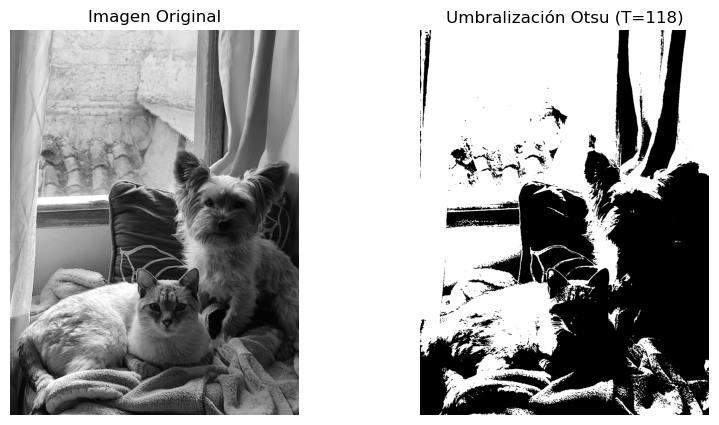

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def otsu_manual(imagen):
   
 
    histograma, _ = np.histogram(imagen.flatten(), bins=256, range=[0,256])

    histograma = histograma.astype(np.float32) / imagen.size

   
    mejor_umbral = 0
    mejor_varianza = 0
    P1, P2 = 0, 0  
    mu1, mu2 = 0, 0  

   
    media_global = np.sum(np.arange(256) * histograma)

   
    suma_clase1 = 0  
    prob_clase1 = 0  

   
    for t in range(256):
        prob_clase1 += histograma[t] 
        if prob_clase1 == 0 or prob_clase1 == 1:  
            continue

        suma_clase1 += t * histograma[t]  
        media_clase1 = suma_clase1 / prob_clase1  

        
        media_clase2 = (media_global - suma_clase1) / (1 - prob_clase1)

      
        varianza_interclase = prob_clase1 * (1 - prob_clase1) * (media_clase1 - media_clase2) ** 2

        
        if varianza_interclase > mejor_varianza:
            mejor_varianza = varianza_interclase
            mejor_umbral = t

    
    imagen_binaria = (imagen > mejor_umbral).astype(np.uint8) * 255

    return mejor_umbral, imagen_binaria

# Cargar imagen en escala de grises
imagen = cv2.imread('imagentango.jpg', cv2.IMREAD_GRAYSCALE)

# Aplicar Otsu manualmente
umbral_otsu, imagen_otsu = otsu_manual(imagen)

# Mostrar resultados
plt.figure(figsize=(15,5))

# Imagen original
plt.subplot(1,3,1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

# Imagen umbralizada
plt.subplot(1,3,2)
plt.imshow(imagen_otsu, cmap="gray")
plt.title(f"Umbralización Otsu (T={umbral_otsu})")
plt.axis("off")



plt.show()